# Comparative reporting

Step-by-step notebook for comparing flat evaluation runs with `soda_mmqc.reporting`.

We build one comparison view at a time. We load **both models** up front; later steps will compare models as well as prompts.

Views so far: **Structure (Layer S)**, **Applicability (Layer 1)**, and **Matching (Layer 2)** — each with prompt/model multiplots and culprit tables.

| | |
|--|--|
| **Check** | `micrograph-scale-bar` |
| **Models** | `gpt-5-mini-2025-08-07`, `gpt-5` |
| **Prompts** | `prompt.1`, `prompt.2`, `prompt.3` |

Run with the project venv (`uv sync`) from the repo root.

## Setup

In [1]:
from __future__ import annotations

import pandas as pd

from soda_mmqc.reporting import (
    load_flat_runs,
    plot_comparison_layer1,
    plot_comparison_layer2_binary,
    plot_comparison_layer2_graded,
    plot_comparison_layer_s,
    show_instance_context,
    show_layer1_errors,
    show_layer2_errors,
    show_table,
    summarize_runs,
)
from soda_mmqc.reporting.styles import (
    LAYER1_TITLE,
    LAYER2_BINARY_TITLE,
    LAYER2_GRADED_TITLE,
    LAYER_S_TITLE,
)

CHECKLIST = "fig-checklist"
CHECK = "micrograph-scale-bar"
MODELS = ["gpt-5-mini-2025-08-07", "gpt-5"]
PROMPTS = ["prompt.1", "prompt.2", "prompt.3"]

# Selectors — change these to focus each comparison view
MODEL = "gpt-5"
PROMPT = "prompt.2"  # scale-bar applicability outliers on this check
CULPRIT_LAYER1 = "spurious_applicable"  # initial culprit-table filter

LAYER_S_FIG_HEIGHT = 300
LAYER_S_FIG_WIDTH = 500
LAYER1_FIG_HEIGHT = 700
LAYER1_FIG_WIDTH = 1200
LAYER2_FIG_HEIGHT = 500
LAYER2_FIG_WIDTH = 1200


2026-06-15 13:40:13 - INFO - ✅ OpenAI API provider configured


### Load runs and summarize

Load all `(model, prompt)` pairs we will need for prompt and model contrasts. One `RunSummary` per pair. Layer S counts live in `by_list_row_counts` (keyed by predictive list, usually `outputs`).

In [2]:
runs = load_flat_runs(
    CHECKLIST,
    CHECK,
    models=MODELS,
    prompts=PROMPTS,
)
summaries = summarize_runs(runs)

pd.DataFrame(
    [
        {
            "model": run.model,
            "prompt": run.prompt,
            "records": len(run.records),
            "by_list_keys": ", ".join(
                summaries[run.model, run.prompt].by_list_keys
            ),
        }
        for run in runs
    ]
)

,model,prompt,records,by_list_keys
0,gpt-5-mini-2025-08-07,prompt.1,14,outputs
1,gpt-5-mini-2025-08-07,prompt.2,14,outputs
2,gpt-5-mini-2025-08-07,prompt.3,14,outputs
3,gpt-5,prompt.1,14,outputs
4,gpt-5,prompt.2,14,outputs
5,gpt-5,prompt.3,14,outputs


## Structural reporting

Reporting whether the lists of objects, ie. the panels, are correct, missing or spurious on this check.

In [3]:
fig_layer_s = plot_comparison_layer_s(
    summaries,
    compare="prompt",
    model=MODEL,
)
if fig_layer_s is None:
    print(f"No {LAYER_S_TITLE} data for model={MODEL}")
else:
    fig_layer_s.update_layout(
        height=LAYER_S_FIG_HEIGHT,
        width=LAYER_S_FIG_WIDTH,
        autosize=True,
        margin=dict(l=40, r=20, t=50, b=40),
    )
    fig_layer_s.show()

## Applicability reporting (Layer 1)

Per leaf field: stacked applicability outcomes. One subplot per field; prompts or models on the x-axis within each panel.

### Comparing prompts

Subplot grid for `MODEL` (default `gpt-5`): three stacked bars per panel (one per prompt, distinguished by **opacity**).

In [4]:
fig_layer1_prompt = plot_comparison_layer1(
    summaries,
    compare="prompt",
    model=MODEL,
)
fig_layer1_prompt.update_layout(
    height=LAYER1_FIG_HEIGHT,
    width=LAYER1_FIG_WIDTH,
    autosize=True,
)
fig_layer1_prompt.show()

### Comparing models

Same layout for `PROMPT` (default `prompt.2`). Models on the x-axis; distinguished by **bar hatching**.

In [5]:
fig_layer1_model = plot_comparison_layer1(
    summaries,
    compare="model",
    prompt=PROMPT,
)
fig_layer1_model.update_layout(
    height=LAYER1_FIG_HEIGHT,
    width=LAYER1_FIG_WIDTH,
    autosize=True,
)
fig_layer1_model.show()

### Applicability culprits

Instance table for one `(MODEL, PROMPT)` pair. Pre-filtered to `CULPRIT_LAYER1`; adjust filters in the table footer.

In [6]:
summary_selected = summaries[MODEL, PROMPT]

show_layer1_errors(
    summary_selected,
    layer1=CULPRIT_LAYER1,
    caption=(
        f"Layer 1 culprits — {CHECK} / {MODEL} / {PROMPT} "
        f"(initial filter: {CULPRIT_LAYER1})"
    ),
)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


## Matching reporting (Layer 2)

This check mixes **binary** fields (e.g. `micrograph`, `scale_bar_*`) and **graded** string fields (e.g. `from_the_caption`). One subplot per field in each chart.

### Matching-binary — comparing prompts

Subplot grid for `MODEL`: stacked TP/TN/FP/FN; prompts distinguished by **opacity**.

In [7]:
fig_layer2_binary_prompt = plot_comparison_layer2_binary(
    summaries,
    compare="prompt",
    model=MODEL,
)
fig_layer2_binary_prompt.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_binary_prompt.show()

### Matching-binary — comparing models

Same layout for `PROMPT`; models distinguished by **bar hatching**.

In [8]:
fig_layer2_binary_model = plot_comparison_layer2_binary(
    summaries,
    compare="model",
    prompt=PROMPT,
)
fig_layer2_binary_model.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_binary_model.show()

### Matching-graded — comparing prompts

Graded string fields only (`match` / `mismatch` stacks).

In [9]:
fig_layer2_graded_prompt = plot_comparison_layer2_graded(
    summaries,
    compare="prompt",
    model=MODEL,
)
fig_layer2_graded_prompt.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_graded_prompt.show()

### Matching-graded — comparing models

In [10]:
fig_layer2_graded_model = plot_comparison_layer2_graded(
    summaries,
    compare="model",
    prompt=PROMPT,
)
fig_layer2_graded_model.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_graded_model.show()

### Matching culprits

Instance-level layer-1 outliers and layer-2 errors for one `(MODEL, PROMPT)` pair.

In [11]:
show_layer2_errors(
    summaries[MODEL, PROMPT],
    caption=f"Layer 2 culprits — {CHECK} / {MODEL} / {PROMPT}",
)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


## Instance drill-down

Pick a row from a culprit table (`doc_id`, `path`, `leaf_property`) and inspect the scored instance plus gold vs pred in context — figure image, parent output row, and leaf field.

**Example context** — `fig-checklist` / `micrograph-scale-bar` / `gpt-5` / `prompt.2`  
`doc_id=10.1038_s44318-026-00715-1` · `steps=['outputs', 1, 'from_the_image']`

**Caption** (10.1038_s44318-026-00715-1/content/1)  
Figure 1: CtpC and CtpG collaborate to confer cadmium tolerance in M. tuberculosis. (A) Genomic organization of pacL, ctp, and adjacent genes on the M. tuberculosis chromosome. pacL1-ctpC, cmtR-pacL2-ctpG, and csoR-pacL3-ctpV form operons in which cmtR and csoR encode the transcriptional regulators controlling their downstream genes. (B–D) Metal sensitivity of M. smegmatis strains harboring a genome-integrative vector expressing the indicated M. tuberculosis pacL-ctp genes under the control of an anhydrotetracycline (ATC)-inducible promoter (tet), assessed by disk diffusion assay upon exposure to zinc (ZnSO4), cadmium (CdSO4), or copper (CuSO4) in the presence of the inducer. Inhibition zone diameters normalized to the empty vector control are shown as mean ± SEM from biological replicates, with individual values indicated by gray dots. Asterisks above the means indicate statistically significant differences compared to the reference strain (**P < 0.01; ****P < 0.0001), calculated by one-way analysis of variance (ANOVA) followed by a Dunnett post-test. Exact p values and biological replicate numbers are reported in Table EV6. (E–H) Bacterial growth of the indicated M. tuberculosis strains in the absence or presence of the specified metals (20 µM CdSO4 and 50 µM ZnSO4), evaluated by turbidity measurements (McFarland units). Data represent mean ± SEM of three independent biological replicates. ∆pacL2-ctpGcomp: ectopic expression of the cmtR-pacL2-ctpG operon under the control of its native promoter in the ∆pacL2-ctpG mutant background.

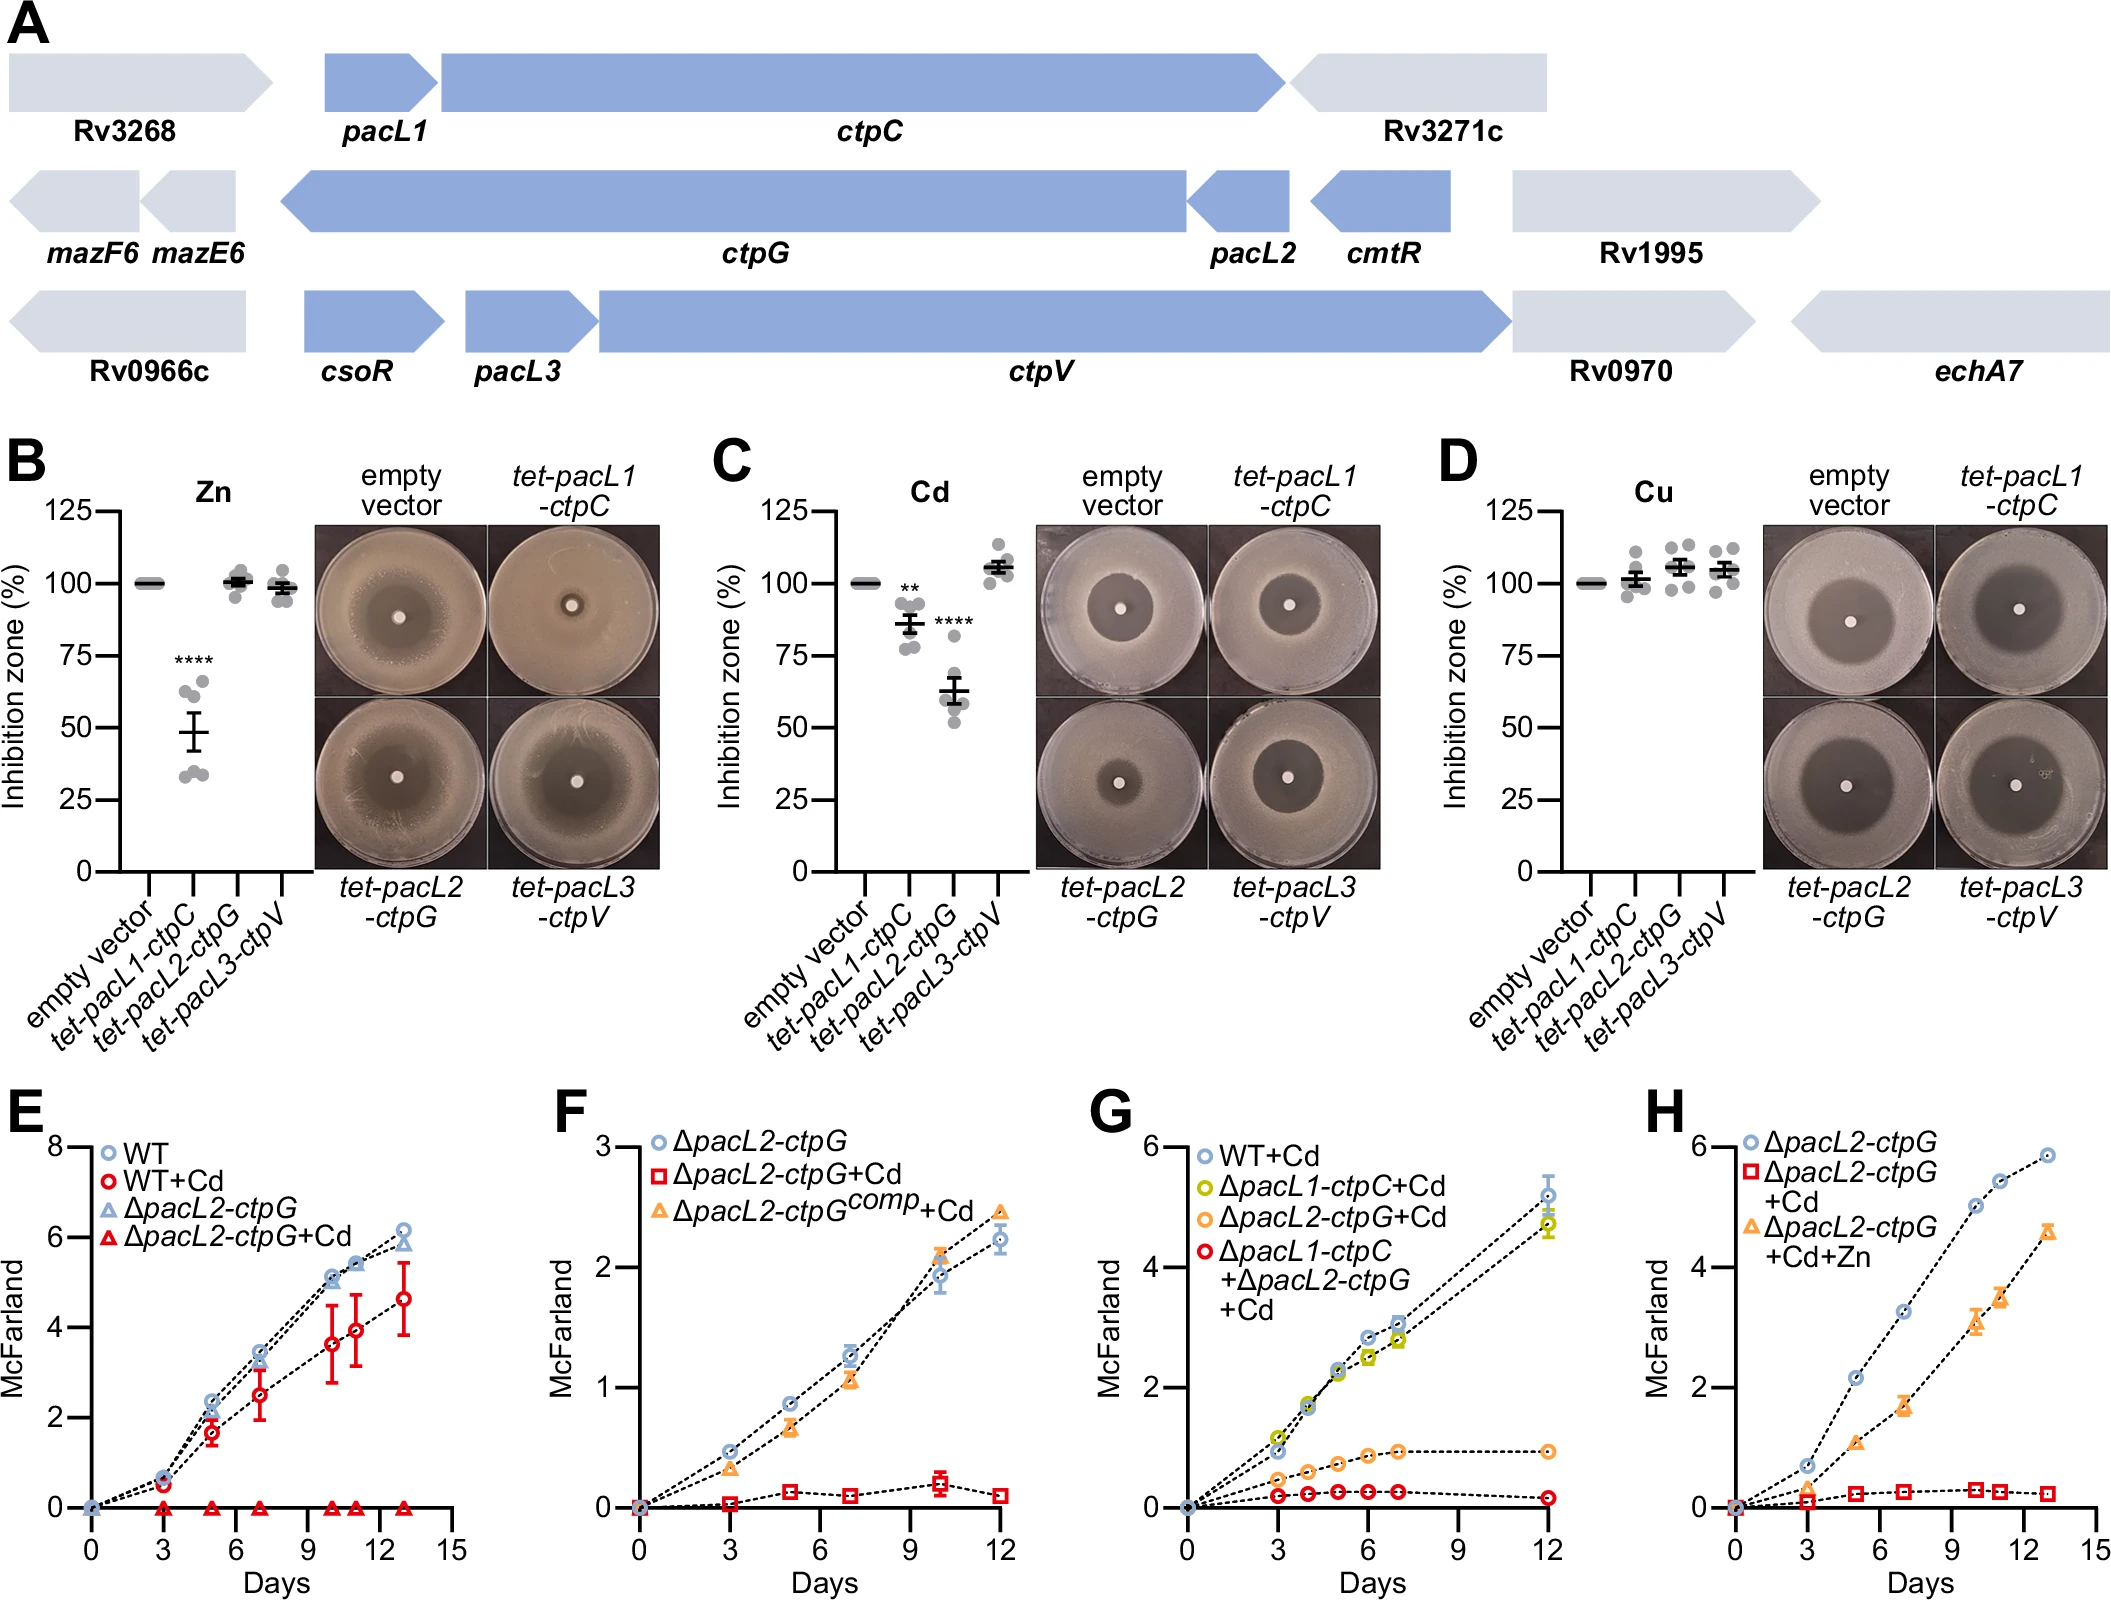

**At steps (gold vs pred)**

,gold,pred
0,'',''


**Parent row (gold vs pred)**

,gold row,pred row
0,"{\n ""panel_label"": ""B"",\n ""micrograph"": ""no""...","{\n ""panel_label"": ""B"",\n ""micrograph"": ""no""..."


**Leaf field `from_the_image` (gold vs pred)**

,gold,pred
0,'',''


In [12]:
# Selectors — copy from a culprit table row
DRILL_DOC_ID = "10.1038_s44318-026-00715-1"
DRILL_OBJECT_PATH = "outputs[1]"
DRILL_LEAF = "from_the_image"

show_instance_context(
    summaries[MODEL, PROMPT],
    doc_id=DRILL_DOC_ID,
    object_path=DRILL_OBJECT_PATH,
    leaf=DRILL_LEAF,
)